In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
%matplotlib inline

In [2]:
df = pd.read_csv("../global_bleaching_environmental.csv")

/tmp/ipykernel_56293/1993203370.py:1: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../global_bleaching_environmental.csv")


In [3]:
numeric_cols = ['Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore',
       'Turbidity', 'Cyclone_Frequency', 'Date_Year', 'Depth_m',
       'Percent_Bleaching', 'ClimSST',
       'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum',
       'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation',
       'Windspeed', 'SSTA', 'SSTA_Standard_Deviation',
       'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency',
       'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax',
       'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation',
       'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation',
       'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency',
       'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'Date_Month',
       'TSA_DHWMax', 'TSA_DHWMean',] # ssta_mean = 0

drop_columns = ['Site_ID', 'Sample_ID', 'Data_Source','Ocean_Name', 'Reef_ID', 'Realm_Name',
       'Ecoregion_Name', 'Country_Name', 'State_Island_Province_Name',
       'City_Town_Name', 'Site_Name', 'Date_Day',
       'Substrate_Name', 'Site_Comments', 'Sample_Comments',
       'Bleaching_Comments', 'Bleaching_Level', 'Percent_Cover', 'SSTA_Mean',
       ] # Exposure - interesting

df.drop(columns= drop_columns, inplace= True)


for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df[df['Date_Year'] >= 1997]
df = df[df['SSTA'] > 0]
df = df.dropna(subset=['Percent_Bleaching'])

# df = df.dropna()

In [4]:
df.shape

(21928, 43)

In [5]:
exposure_dummies = pd.get_dummies(df['Exposure'], prefix='Exposure', drop_first=False)
df = pd.concat([df, exposure_dummies], axis=1)
df = df.drop(columns=['Exposure', 'Date_Year', 'Date'])

In [6]:
df.columns

Index(['Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore',
       'Turbidity', 'Cyclone_Frequency', 'Date_Month', 'Depth_m',
       'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'Exposure_Exposed', 'Exposure_Sheltered',
       'Exposure_Sometimes'],
      dtype='object')

# PCA

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
X = df.drop("Percent_Bleaching", axis=1)
Y = df["Percent_Bleaching"]

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
X_train_raw_exposure, X_test_raw_exposure = X_train_raw[['Exposure_Exposed', 'Exposure_Sheltered', 'Exposure_Sometimes']].copy(), \
                                             X_test_raw[['Exposure_Exposed', 'Exposure_Sheltered', 'Exposure_Sometimes']].copy()

X_train_raw = X_train_raw.drop(columns=['Exposure_Exposed', 'Exposure_Sheltered', 'Exposure_Sometimes'])
X_test_raw = X_test_raw.drop(columns=['Exposure_Exposed', 'Exposure_Sheltered', 'Exposure_Sometimes'])

In [10]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [11]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

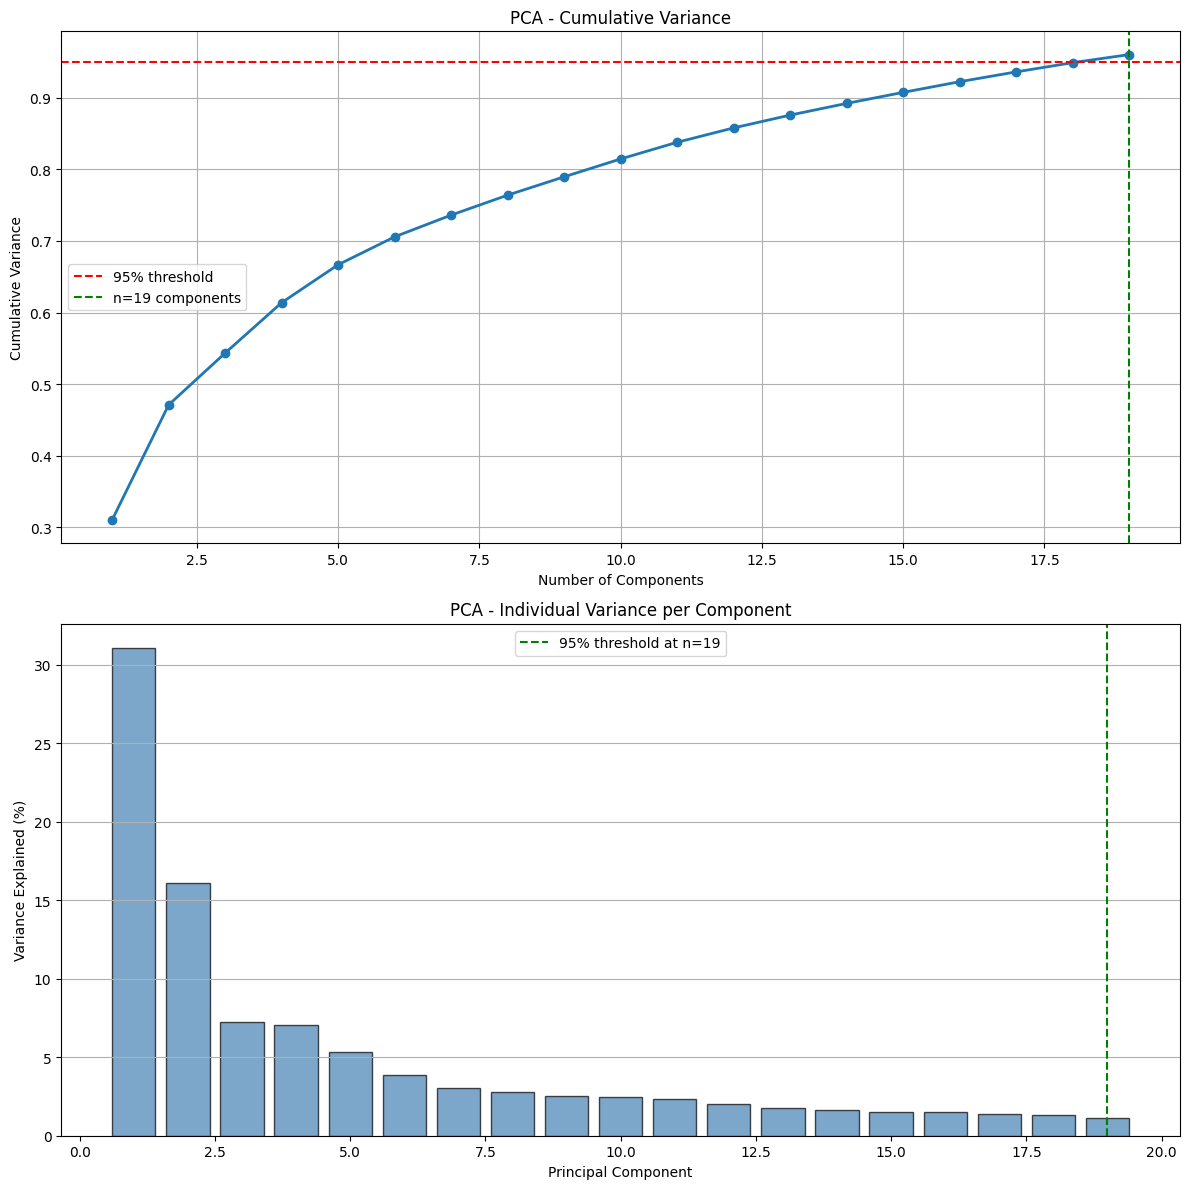

✅ Components needed for 95% variance: 19
✅ Variance explained by 19 components: 0.9603


In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'n={n_components_95} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'95% threshold at n={n_components_95}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Variance explained by {n_components_95} components: {cumvar[n_components_95-1]:.4f}")

In [12]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_exposure = X_train_raw_exposure.reset_index(drop=True)
X_test_raw_exposure = X_test_raw_exposure.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_exposure], axis=1)
X_test_pca = pd.concat([X_test_pca_df, X_test_raw_exposure], axis=1)

# lazyPredict

In [15]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [17]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

                               Adjusted R-Squared    R-Squared        RMSE  \
Model                                                                        
ExtraTreesRegressor                      0.647932     0.649699   12.488954   
RandomForestRegressor                    0.613365     0.615305   13.087699   
XGBRegressor                             0.585871     0.587949   13.545048   
BaggingRegressor                         0.580529     0.582634   13.632135   
HistGradientBoostingRegressor            0.502356     0.504853   14.848145   
KNeighborsRegressor                      0.501564     0.504065   14.859963   
MLPRegressor                             0.426664     0.429541   15.937397   
DecisionTreeRegressor                    0.381171     0.384275   16.557641   
GradientBoostingRegressor                0.346567     0.349845   17.014278   
ExtraTreeRegressor                       0.310579     0.314038   17.476533   
NuSVR                                    0.205440     0.209426  

In [13]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, VotingRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# OpTuna

In [15]:
exposure_cols = ['Exposure_Exposed', 'Exposure_Sheltered', 'Exposure_Sometimes']

X_train_no_exposure = X_train_raw.copy()  
X_train_exposure    = X_train_raw_exposure.reset_index(drop=True)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_exposure (pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [19]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int("n_estimators", 50, 300),
        max_depth        = trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_exposure(pipeline, X_train_no_exposure , X_train_exposure , y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

[I 2026-05-06 00:28:10,057] A new study created in memory with name: no-name-12b61ece-8fd9-4687-90c9-621130201ec1
[I 2026-05-06 00:28:11,641] Trial 0 finished with value: 0.4406824830290748 and parameters: {'n_estimators': 218, 'max_depth': 18, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.4406824830290748.
[I 2026-05-06 00:28:13,450] Trial 1 finished with value: 0.5173575618600186 and parameters: {'n_estimators': 251, 'max_depth': 37, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.5173575618600186.
[I 2026-05-06 00:28:15,659] Trial 2 finished with value: 0.5585736853917452 and parameters: {'n_estimators': 268, 'max_depth': 32, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.5585736853917452.
[I 2026-05-06 00:28:16,654] Trial 3 finished with value: 0.26986431818609813 and parameters: {'n_estimators': 160, 'max_depth': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 2 with valu

========== ET BEST ==========
{'n_estimators': 299, 'max_depth': 33, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best R²: 0.5916


In [20]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 300),
        max_depth         = trial.suggest_int("max_depth", 5, 40),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_exposure (pipeline, X_train_no_exposure , X_train_exposure , y_train)

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=50)
print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

[I 2026-05-06 00:29:54,778] A new study created in memory with name: no-name-926cc0b6-86eb-473a-a054-51b9974ba9bf
[I 2026-05-06 00:29:57,300] Trial 0 finished with value: 0.5385659204630289 and parameters: {'n_estimators': 115, 'max_depth': 40, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.5385659204630289.
[I 2026-05-06 00:30:02,018] Trial 1 finished with value: 0.570033495447885 and parameters: {'n_estimators': 213, 'max_depth': 38, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.570033495447885.
[I 2026-05-06 00:30:05,625] Trial 2 finished with value: 0.5275253342483243 and parameters: {'n_estimators': 187, 'max_depth': 37, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.570033495447885.
[I 2026-05-06 00:30:10,271] Trial 3 finished with value: 0.5514788016336287 and parameters: {'n_estimators': 252, 'max_depth': 16, 'min_

========== RF BEST ==========
{'n_estimators': 179, 'max_depth': 38, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best R²: 0.5841


In [17]:
def xgb_objective(trial):
    model = xgb.XGBRegressor(
        n_estimators     = trial.suggest_int  ("n_estimators",   50, 400),
        learning_rate    = trial.suggest_float("learning_rate", 0.005, 0.1),
        max_depth        = trial.suggest_int  ("max_depth",       3,  15),
        subsample        = trial.suggest_float("subsample",      0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree",0.5, 1.0),
        device='cuda',           # ← ใช้ GPU
        tree_method='hist',      # ← จำเป็นกับ GPU
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_exposure(pipeline, X_train_no_exposure, X_train_exposure, y_train)

xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=50)
print("========== XGB BEST ==========")
print(xgb_study.best_params)
print(f"Best R²: {xgb_study.best_value:.4f}")

[I 2026-05-06 00:40:06,194] A new study created in memory with name: no-name-62ac33d7-e654-4d1f-b47d-2cf5c5d89b2b
/home/winkawin2552/code/Bleached-coral/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [00:40:07] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-05-06 00:40:12,364] Trial 0 finished with value: 0.5979610059762166 and parameters: {'n_estimators': 288, 'learning_rate': 0.08970981938037312, 'max_depth': 9, 'subsample': 0.700910475320135, 'colsample_bytree': 0.7357153355894226}. Best is trial 0 with value: 0.5979610059762166.
[I 2026-

========== XGB BEST ==========
{'n_estimators': 382, 'learning_rate': 0.022508404412725832, 'max_depth': 14, 'subsample': 0.5815588043007949, 'colsample_bytree': 0.732711312981946}
Best R²: 0.6053


# Start

In [18]:
et_model = ExtraTreesRegressor(
    n_estimators=299,
    max_depth=33,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 299, 'max_depth': 33, 'min_samples_leaf': 1, 'max_features': 'log2'}

rf_model = RandomForestRegressor(
    n_estimators=179,
    max_depth=38,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 179, 'max_depth': 38, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}


xgb_model = xgb.XGBRegressor(
    n_estimators=382,
    learning_rate=0.0225,
    max_depth=14,
    subsample=0.581,
    colsample_bytree=0.7327,
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 382, 'learning_rate': 0.022508404412725832, 'max_depth': 14, 'subsample': 0.5815588043007949,
#  'colsample_bytree': 0.732711312981946}


In [19]:
voting_model = VotingRegressor([
    ('et',  et_model),
    ('rf',  rf_model),
    ('xgb', xgb_model)
])

# Train all 5
et_model.fit(X_train_pca, y_train)
rf_model.fit(X_train_pca, y_train)
xgb_model.fit(X_train_pca, y_train)
voting_model.fit(X_train_pca, y_train)

# Evaluate
models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'XGBoost':              xgb_model,
    'Voting (Ensemble)':    voting_model
}

print("=" * 65)
print("BASELINE RESULTS (single seed = 42)")
print("=" * 65)
print(f"{'Model':<22}{'R²':>10}{'RMSE':>12}{'MAE':>10}{'Acc%':>10}")
print("-" * 65)
for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"{name:<22}{r2:>10.4f}{rmse:>12.4f}{mae:>10.4f}{100-mae:>10.2f}")
print("-" * 65)
print(f"{'Paper baseline:':<22}{0.6395:>10.4f}{12.9268:>12.4f}{'—':>10}{93.88:>10.2f}")
print("=" * 65)

BASELINE RESULTS (single seed = 42)
Model                         R²        RMSE       MAE      Acc%
-----------------------------------------------------------------
ExtraTrees                0.6444     12.5831    5.5664     94.43
RandomForest              0.6218     12.9768    6.7006     93.30
XGBoost                   0.6506     12.4727    6.0080     93.99
Voting (Ensemble)         0.6486     12.5087    6.0416     93.96
-----------------------------------------------------------------
Paper baseline:           0.6395     12.9268         —     93.88


# K-Fold

In [20]:
from sklearn.model_selection import KFold
exposure_cols = ['Exposure_Exposed', 'Exposure_Sheltered', 'Exposure_Sometimes']

X_exposure    = X[exposure_cols].copy()
X_no_exposure = X.drop(columns=exposure_cols)

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'XGBoost':              xgb_model,
    'Voting (Ensemble)':    VotingRegressor([
        ('et',  et_model),
        ('rf',  rf_model),
        ('xgb', xgb_model)
    ])
}

print("=" * 70)
print("K-Fold Cross Validation Summary (k=4)")
print("=" * 70)
print(f"{'Model':<22}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 70)

for name, base_model in cv_models.items():
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, test_idx in kf.split(X_no_exposure):
        X_fold_train, X_fold_test = X_no_exposure.iloc[train_idx], X_no_exposure.iloc[test_idx]
        exposure_fold_train = X_exposure.iloc[train_idx].reset_index(drop=True)
        exposure_fold_test  = X_exposure.iloc[test_idx].reset_index(drop=True)
        y_fold_train        = Y.iloc[train_idx].reset_index(drop=True)
        y_fold_test         = Y.iloc[test_idx].reset_index(drop=True)

        # Impute → Scale → PCA (numeric only)
        imputer     = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_fold_train)
        X_test_imp  = imputer.transform(X_fold_test)

        scaler      = StandardScaler()
        X_train_ss  = scaler.fit_transform(X_train_imp)
        X_test_ss   = scaler.transform(X_test_imp)

        pca         = PCA(n_components=0.95)
        X_train_pca = pca.fit_transform(X_train_ss)
        X_test_pca  = pca.transform(X_test_ss)

        # Reattach exposure columns after PCA
        n_pcs   = X_train_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_train_final = pd.concat([pd.DataFrame(X_train_pca, columns=pc_cols), exposure_fold_train], axis=1)
        X_test_final  = pd.concat([pd.DataFrame(X_test_pca,  columns=pc_cols), exposure_fold_test ], axis=1)

        from sklearn.base import clone
        model = clone(base_model)
        model.fit(X_train_final, y_fold_train)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_fold_test, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
        mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(f"{name:<22}{np.mean(r2_scores):>14.4f}{np.mean(rmse_scores):>14.4f}{np.mean(mae_scores):>14.4f}")

print("=" * 70)

K-Fold Cross Validation Summary (k=4)
Model                        Mean R²     Mean RMSE      Mean MAE
----------------------------------------------------------------------
ExtraTrees                    0.6302       13.0920        5.9004
RandomForest                  0.6182       13.3014        6.9586
XGBoost                       0.6397       12.9223        6.3366
Voting (Ensemble)             0.6388       12.9388        6.3481
